# SSM-3 — Mamba-2 and the duality (SSD)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm3-mamba2-ssd.ipynb)

**The question:** if the SSM and linear attention are both linear recurrences, are they the same thing?

Prerequisites: [SSM-2](ssm2-selectivity.ipynb), [M3](../../foundations/m3-linear-attention.ipynb), [M7](../../foundations/m7-three-dials.ipynb).

Selectivity made the gate input-dependent, and because the state matrix is diagonal, that gate is channel-wise: each of the $N$ modes carries its own decay $\bar A_t$. Mamba-2 adds one restriction on top. Force the state matrix to be a scalar times the identity, $A_t=a_tI$, so a single number gates the entire state at every step instead of one number per mode. The restriction costs expressiveness, and in exchange it buys a closed form. With a scalar gate the whole sequence-to-sequence map is a single matrix $M$, and that matrix turns out to be a decay-masked $CB^\top$: the masked linear attention of M3, read with $C$ as the queries, $B$ as the keys, and the input as the values. The SSM and linear attention are one computation seen from two sides, which Dao and Gu name the structured state-space duality.

> Grounding: [Mamba-2 / SSD](https://arxiv.org/abs/2405.21060) (Dao & Gu, 2024). §3 (Def. 3.1–3.2, Eqs. 3–4, Theorem 3.5) for the SSM as a semiseparable matrix; §3.2.2 (Eqs. 6–7) for the 1-semiseparable scalar recurrence; §5.1–§5.3 (Corollary 5.1) for the scalar-identity restriction and the duality; §6 (Theorem 6.1, Listing 1) for the chunked algorithm. Equations are cited by section and number; anything I derive is marked as mine.

## Objective

After this module you should be able to:

- Write the SSM as a sequence-to-sequence matrix $M$ with $M_{ij}=C_i^\top A_{i:j}B_j$ (output index $i$, input index $j\le i$, and $A_{i:j}=\prod_{k=j+1}^{i}A_k$), and recognize $M$ as **N-semiseparable**: every block below the diagonal has rank at most $N$ (Mamba-2 Def. 3.1, Theorem 3.5).
- Restrict the state matrix to a scalar, $A_t=a_tI$, and collapse $M$ to $L\circ(CB^\top)$ with the decay mask $L_{ij}=\prod_{k=j+1}^{i}a_k$ (Mamba-2 §5.1).
- Read that as **masked linear attention**: queries $q_i=C_i$, keys $k_j=B_j$, values $v_j=x_j$, and mask $L$; recover M3's linear attention as the special case $a_t=1$ (Mamba-2 Corollary 5.1).
- State the **duality**: the same $M$ has a linear recurrent form ($O(T)$) and a quadratic attention form ($O(T^2)$), and the chunked block decomposition interpolates between them (Mamba-2 Theorem 6.1).
- Give the module's dial setting: an additive (Hebbian) write with a selective **scalar** gate $\alpha_t=a_t$, which is M7 §5's gated-Hebbian row.

## Why it exists (the connection it makes)

Selectivity left the memory more expressive than the plain SSM, at a price. The gate $\bar A_t$ became input-dependent, so a token could set its own decay, and because the state matrix stays diagonal the gate is channel-wise: $N$ independent modes, each with its own per-token decay. That is more knobs than linear attention has, and it broke the single convolution the plain SSM relied on (SSM-2 §3).

Mamba-2 asks what the memory gives up if the gate is forced to be uniform across modes. Set the state matrix to a scalar multiple of the identity, $A_t=a_tI$, so one scalar $a_t$ decays the whole state at each step. The channel-wise freedom is gone; a single per-token number remains. The reason to accept that trade is what the restriction reveals. A scalar gate makes the sequence transform a matrix of the form $L\circ(CB^\top)$, which is exactly masked linear attention, so the SSM line rejoins the linear-attention line M3 built from the Transformer side. Unlike the earlier modules, nothing here is broken and then repaired; the scalar restriction is the price of admission to a bridge joining two families the course has so far treated separately. This module makes that identity concrete and numerical, and then locates the scalar-gated SSM on M7's dials.

### Reading

- [Mamba-2 / SSD](https://arxiv.org/abs/2405.21060) (Dao & Gu, 2024): §3.1–§3.2 — state space models as semiseparable matrix transformations (Def. 3.1, N-semiseparable; Def. 3.2, the SSS representation, Eq. 4; Theorem 3.5); §3.2.2 (Eqs. 6–7) — 1-semiseparable matrices and the scalar recurrence $y_t=a_ty_{t-1}+x_t$; §4.1.4 (Eqs. 10–13) — masked kernel attention $y=(L\circ(QK^\top))V$; §5.1 — the scalar-identity restriction $M=L\circ(CB^\top)$; §5.2 (Corollary 5.1) — 1-SS masked attention as a scalar-identity diagonal SSM; §5.3 — the duality summary; §6 (Theorem 6.1, Listing 1) — the chunked algorithm. The grounding source; every equation below is cited to it.

## 1. The SSM is a semiseparable matrix

Take the selective SSM from SSM-2 and write its whole action on a sequence as one matrix. With state $h_t$ evolving by $h_t=\bar A_t h_{t-1}+B_t x_t$ and output $y_t=C_t^\top h_t$, unrolling the recurrence gives each output as a weighted sum of every past input:

$$y_i=\sum_{j\le i} C_i^\top\Big(\prod_{k=j+1}^{i}\bar A_k\Big)B_j\,x_j=\sum_{j\le i} M_{ij}\,x_j,\qquad M_{ij}=C_i^\top\Big(\prod_{k=j+1}^{i}\bar A_k\Big)B_j.$$

So the sequence-to-sequence map is multiplication by a single lower-triangular matrix $M$, with $M_{ij}=0$ for $j>i$ (Mamba-2 Eqs. 3–4, written output-first; the paper indexes the same entry as $M_{ji}$). This $M$ is not an arbitrary matrix. Every entry on or below the diagonal is a product $C_i^\top(\cdots)B_j$ that funnels through the $N$-dimensional state, so any block drawn from strictly below the diagonal factors as a $C$-side matrix times an $A$-product times a $B$-side matrix, each of inner dimension $N$. A matrix whose every below-diagonal block has rank at most $N$ is called **N-semiseparable** (Mamba-2 Def. 3.1), and Theorem 3.5 states that the SSM transform is exactly multiplication by such a matrix. That rank bound is the structure the rest of the module exploits.

The cell builds $M$ for the channel-wise (diagonal) SSM, checks $y=Mx$ against the step-by-step recurrence, and reads the singular values of one off-diagonal block.

In [1]:
import torch

torch.manual_seed(0)

T, N, P = 12, 4, 3          # sequence length; state dim (d_k, the B/C size); head/value dim (d_v)

# The selective SSM from SSM-2: time-varying, channel-wise (diagonal) gate -- one decay per mode.
Adiag = torch.sigmoid(torch.randn(T, N))     # diagonal Abar_t in (0,1)^N
B = torch.randn(T, N)                          # input map  B_t   (becomes the key  once A is scalar)
C = torch.randn(T, N)                          # output map C_t   (becomes the query)
X = torch.randn(T, P)                          # the sequence, P-dim per token (becomes the value)

def ssm_recurrence(Agate, B, C, X):
    # H_t = Agate_t . H_{t-1} + B_t x_t^T ;  y_t = C_t^T H_t .  State H is N x P.
    # Agate_t is a length-N vector (channel-wise) or a scalar (section 2 onward).
    N_, P_ = B.shape[1], X.shape[1]
    H = torch.zeros(N_, P_)
    Y = torch.zeros(X.shape[0], P_)
    for t in range(X.shape[0]):
        g = Agate[t][:, None] if Agate.dim() == 2 else Agate[t]
        H = g * H + torch.outer(B[t], X[t])
        Y[t] = C[t] @ H
    return Y

def ssm_matrix(Adiag, B, C):
    # M_ij = C_i^T ( prod_{k=j+1..i} diag(Abar_k) ) B_j  for j <= i, else 0  (Mamba-2 Eq. 3-4).
    T_, N_ = Adiag.shape
    cum = torch.cumsum(torch.log(Adiag), dim=0)          # cumulative log-decay, per mode
    M = torch.zeros(T_, T_)
    for i in range(T_):
        for j in range(i + 1):
            prodA = torch.exp(cum[i] - cum[j])           # elementwise product of gates over modes
            M[i, j] = (C[i] * prodA * B[j]).sum()        # C_i^T diag(prod) B_j
    return M

Y_rec_diag = ssm_recurrence(Adiag, B, C, X)
M = ssm_matrix(Adiag, B, C)
print("y = M x  matches the step-by-step recurrence:", torch.allclose(M @ X, Y_rec_diag, atol=1e-5))

# semiseparable (Mamba-2 Def. 3.1): any block strictly below the diagonal has rank at most N.
block = M[6:12, 0:6]                                     # a 6x6 block from the lower-left corner
sv = torch.linalg.svdvals(block)
print("6x6 off-diagonal block singular values:", [f"{s:.3f}" for s in sv.tolist()])
print(f"rank = {torch.linalg.matrix_rank(block, tol=1e-6).item()}  (<= N = {N}), though the block is 6x6")

y = M x  matches the step-by-step recurrence: True
6x6 off-diagonal block singular values: ['0.919', '0.730', '0.077', '0.030', '0.000', '0.000']
rank = 4  (<= N = 4), though the block is 6x6


The matrix form reproduces the recurrence to floating-point tolerance, so the SSM really is multiplication by $M$. The $6\times6$ block from the bottom-left corner has four non-zero singular values and two that are numerically zero, so its rank is $N=4$ where a generic $6\times6$ matrix would have rank $6$. That is the semiseparable property in one number: everything the block can say about how early inputs reach late outputs must pass through the four-dimensional state, and nothing wider survives the bottleneck. The next section restricts that state matrix and watches $M$ turn into something familiar.

## 2. The scalar restriction: $M$ is a decay-masked $CB^\top$

Now impose Mamba-2's restriction. Let the state matrix be a scalar times the identity, $\bar A_t=a_tI$ with $a_t$ a single number (Mamba-2 §5.1). The product $\prod_{k=j+1}^{i}\bar A_k$ becomes $\big(\prod_{k=j+1}^{i}a_k\big)I$, a scalar, and it slides out of the $C_i^\top(\cdots)B_j$ sandwich:

$$M_{ij}=\Big(\prod_{k=j+1}^{i}a_k\Big)\,C_i^\top B_j=L_{ij}\,(C_i^\top B_j),\qquad L_{ij}=\prod_{k=j+1}^{i}a_k\ \ (j\le i),\quad L_{ij}=0\ \ (j>i).$$

In matrix form $M=L\circ(CB^\top)$, an elementwise product of two structured pieces (Mamba-2 §5.1). The factor $CB^\top$ has entries $C_i^\top B_j$, a full table of query-key scores. The factor $L$ is lower-triangular with $L_{ii}=1$ and each below-diagonal entry a running product of the gates between the two positions; it is the 1-semiseparable decay mask, the scalar SSM's own recurrence written as a matrix (Mamba-2 Eqs. 6–7).

Read $M=L\circ(CB^\top)$ as attention and the dictionary is exact. The score $C_i^\top B_j$ is a query-key dot product with **query** $q_i=C_i$ and **key** $k_j=B_j$; the input $x_j$ is the **value** $v_j$; and $L$ is a causal mask that also decays with distance. So the output is

$$y_i=\sum_{j\le i}L_{ij}\,(C_i^\top B_j)\,x_j,$$

which is M3's masked linear attention $y=(L\circ(QK^\top))V$ with one change: M3's mask is a plain causal triangle of ones, and here the ones are replaced by the running decays $L_{ij}$ (Mamba-2 §4.1.4, §5.2). Set every $a_t=1$ and the decays collapse back to ones, recovering plain linear attention exactly. Selectivity survives the restriction: the gates $a_t$ still depend on the input, so $L$ is content-dependent, which Mamba-2 calls the input-dependent generalization of linear attention. What the scalar gate gives up against SSM-2 is the per-mode decay; the per-token gate remains.

The cell builds both forms and checks they agree exactly.

In [2]:
# Mamba-2's restriction (section 5.1): A_t = a_t * I -- one scalar gates the entire state.
a = torch.sigmoid(torch.randn(T))               # scalar gate a_t in (0,1); still input-dependent

def decay_mask(a):
    # L_ij = prod_{k=j+1..i} a_k for j <= i, else 0 (the 1-SS decay mask, Mamba-2 Eq. 6).
    cum = torch.cumsum(torch.log(a), dim=0)
    return torch.tril(torch.exp(cum[:, None] - cum[None, :]))

# quadratic (attention) form:  M = L o (C B^T),  then Y = M X
L = decay_mask(a)
G = C @ B.t()                                    # G_ij = C_i . B_j  =  q_i . k_j
M_scalar = L * G                                 # masked linear-attention matrix
Y_attn = M_scalar @ X                            # y = (L o (Q K^T)) V   with Q=C, K=B, V=X

# linear (recurrence) form: the scalar-A SSM
Y_rec = ssm_recurrence(a, B, C, X)

print("mapping:  q_i = C_i,  k_j = B_j,  v_j = x_j,  mask L_ij = prod_{k=j+1..i} a_k")
print("Assert 1  max |recurrence - masked attention| =", f"{(Y_rec - Y_attn).abs().max().item():.2e}")
assert torch.allclose(Y_rec, Y_attn, atol=1e-5)
print("torch.allclose -> True: the scalar-A SSM is masked linear attention.")

# with every gate a_t = 1 the decay mask is M3's plain causal triangle of ones
L_ones = decay_mask(torch.ones(T))
print("a_t = 1 -> L is the causal mask of ones (M3 linear attention):",
      torch.allclose(L_ones, torch.tril(torch.ones(T, T))))

mapping:  q_i = C_i,  k_j = B_j,  v_j = x_j,  mask L_ij = prod_{k=j+1..i} a_k
Assert 1  max |recurrence - masked attention| = 7.86e-07
torch.allclose -> True: the scalar-A SSM is masked linear attention.
a_t = 1 -> L is the causal mask of ones (M3 linear attention): True


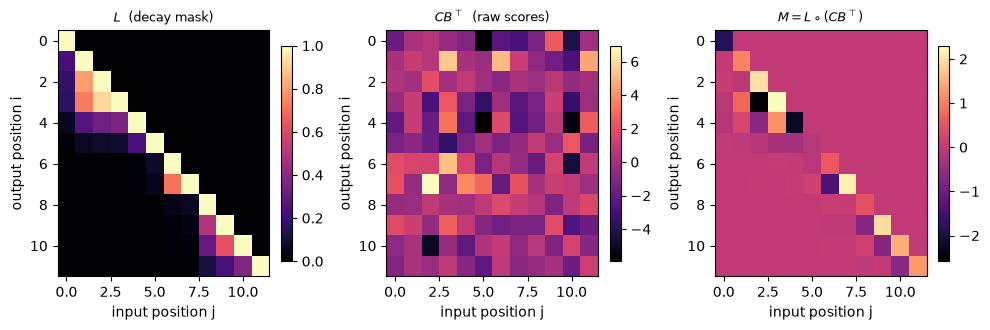

In [3]:
import matplotlib.pyplot as plt

# the decomposition M = L o (C B^T), rendered: decay mask, raw scores, masked-attention matrix
fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
for a_, mat, ttl in [(ax[0], L,        r"$L$  (decay mask)"),
                     (ax[1], G,        r"$CB^\top$  (raw scores)"),
                     (ax[2], M_scalar, r"$M = L \circ (CB^\top)$")]:
    im = a_.imshow(mat, aspect="auto", cmap="magma")
    a_.set_title(ttl, fontsize=9)
    a_.set_xlabel("input position j"); a_.set_ylabel("output position i")
    fig.colorbar(im, ax=a_, fraction=0.046)
plt.tight_layout(); plt.show()

The decay triangle $L$ masks the score matrix $CB^\top$; their elementwise product is $M$, the same lower-triangular structured matrix a causal linear-attention layer applies.

The two outputs match to floating-point tolerance, so the scalar-$A$ SSM and the masked-attention form compute the identical function. The print names the mapping that makes them one object: the SSM's output map $C$ is the attention query, its input map $B$ is the key, the sequence itself is the value, and the accumulated gate is the decay mask. Turning every gate to one leaves $L$ a plain causal triangle, which is M3's linear attention with no forgetting. This is the claim the module exists to cash out, now a numerical identity rather than a sentence: an SSM with a scalar state matrix is a linear attention with a decay mask.

::: {.callout-note collapse="true"}
## Q: If the scalar-A SSM is just masked linear attention, did Mamba-2 throw away SSM-2's selectivity?

No. Selectivity in SSM-2 meant the recurrence parameters depend on the input, and that is still true here. The gate $a_t=\exp(\Delta_t A)$ is a function of the token through $\Delta_t$, so the mask $L$ it generates is content-dependent, and $B_t,C_t$ vary with the token as well. What Mamba-2 restricts is the shape of the state matrix, from a diagonal of $N$ independent decays to a single scalar $a_tI$. SSM-2's gate could fade mode 3 while holding mode 7; Mamba-2's fades every mode by the same factor at a given step.

The paper's reason for accepting the narrower gate is efficiency. The scalar structure is exactly what turns the sequence transform into $L\circ(CB^\top)$, and that form carries both a quadratic attention mode and a linear recurrent mode, plus the chunked algorithm of §3 that runs on matrix-multiply hardware. The channel-wise SSM of SSM-2 keeps the linear mode but has no clean attention dual, so it cannot use the same schedule. Mamba-2 trades a gate it rarely needed at full generality for a computation the GPU runs several times faster (Mamba-2 §5.2, §6).
:::

## 3. The duality: two forms, and the chunked algorithm

The matrix $M$ can be applied to the input in more than one order, and the orders cost differently. This is the same parallel-versus-recurrent duality M3 and SSM-1 already met, now stated for the whole semiseparable class (Mamba-2 §5.3).

The **linear form** is the recurrence of §2: carry the state $S_t$, update it with one scalar-gated outer product per token, and read with $C_t$. It costs $O(T)$ time and holds a fixed-size state, which is the SSM's inference path. The **quadratic form** is the attention of §2: build the full $T\times T$ matrix $M=L\circ(CB^\top)$ and multiply by the values. It costs $O(T^2)$ and is a sequence of matrix multiplies, which is the parallel training path. Same $M$, same result, two schedules.

The **chunked form** interpolates, and it is the reason Mamba-2 is fast (Mamba-2 Theorem 6.1). Cut the sequence into chunks of length $Q$ and partition $M$ into a grid of $Q\times Q$ blocks. A diagonal block is a small self-contained SSM over one chunk, computed in the quadratic attention mode, which is cheap because $Q$ is small and it runs as a matrix multiply. An off-diagonal block connects a later chunk to an earlier one, and by the semiseparable rank bound it factors through the state: summarize each chunk into an end-of-chunk state (the $B$-side factor), carry those states forward by the scalar recurrence across chunks (the $A$-side factor), then expand each entering state into outputs (the $C$-side factor). The diagonal blocks handle what happens inside a chunk and the state recurrence handles what crosses between chunks, so the whole computation is $O(T)$ in length while spending most of its work in matrix multiplies. That is how Mamba-2's core layer reaches 2-8x over Mamba's pure scan while staying linear in sequence length (Mamba-2 §1, §6).

The cell implements the chunked algorithm and checks it against the sequential recurrence.

In [4]:
def ssd_chunked(a, B, C, X, Q):
    # SSD block decomposition (Mamba-2 section 6, Listing 1): scalar a, single head, plain PyTorch.
    T_, N_, P_ = a.shape[0], B.shape[1], X.shape[1]
    nc = T_ // Q
    la = torch.log(a).reshape(nc, Q)
    Bc, Cc, Xc = B.reshape(nc, Q, N_), C.reshape(nc, Q, N_), X.reshape(nc, Q, P_)
    cum = torch.cumsum(la, dim=1)                          # within-chunk cumulative log-decay
    Y = torch.zeros(nc, Q, P_)

    # 1. diagonal blocks: intra-chunk masked attention, initial state 0
    for c in range(nc):
        Lc = torch.tril(torch.exp(cum[c][:, None] - cum[c][None, :]))
        Y[c] = (Lc * (Cc[c] @ Bc[c].t())) @ Xc[c]

    # 2. each chunk's final state from its own inputs (initial state 0) -- B-side factor
    states = torch.zeros(nc, N_, P_)
    for c in range(nc):
        decay_end = torch.exp(cum[c][-1] - cum[c])         # gates from position j to the chunk end
        states[c] = Bc[c].t() @ (Xc[c] * decay_end[:, None])

    # 3. inter-chunk recurrence: carry the state across chunk boundaries -- A-side factor
    chunk_decay = torch.exp(cum[:, -1])                    # total decay across a whole chunk
    enter = torch.zeros(nc, N_, P_)
    run = torch.zeros(N_, P_)
    for c in range(nc):
        enter[c] = run                                     # state entering chunk c
        run = chunk_decay[c] * run + states[c]

    # 4. state -> output: add the entering state's contribution at each position -- C-side factor
    for c in range(nc):
        decay_in = torch.exp(cum[c])                       # gates from the chunk start to position i
        for i in range(Q):
            Y[c, i] = Y[c, i] + (Cc[c, i] @ enter[c]) * decay_in[i]
    return Y.reshape(T_, P_)

Y_chunk = ssd_chunked(a, B, C, X, Q=3)                     # 12 tokens as 4 chunks of length 3
print("Assert 2  max |chunked - recurrence| =", f"{(Y_chunk - Y_rec).abs().max().item():.2e}")
assert torch.allclose(Y_chunk, Y_rec, atol=1e-5)
print("torch.allclose -> True: the chunked block decomposition equals the sequential recurrence.")
print("diagonal blocks = intra-chunk attention;  off-diagonal = a recurrence on chunk-summary states.")

Assert 2  max |chunked - recurrence| = 4.77e-07
torch.allclose -> True: the chunked block decomposition equals the sequential recurrence.
diagonal blocks = intra-chunk attention;  off-diagonal = a recurrence on chunk-summary states.


The chunked output equals the sequential recurrence to floating-point tolerance, so the block decomposition is the same function computed on a third schedule. Nothing about the numbers changed; what changed is that the intra-chunk work became small dense matrix multiplies and the inter-chunk work became a short recurrence over chunk summaries, which is the shape modern hardware runs fastest. The three forms (recurrence, full attention matrix, and chunks) are one matrix $M$ applied three ways, which is the operational content of the duality.

**Scope.** This toy settles two exact identities and nothing about speed. It runs the scalar-$A$ case, which is Mamba-2's actual restriction ($A_t=a_tI$), on tiny dimensions ($T=12$, state $N=4$, head $P=3$), so the semiseparable rank bound and the attention equivalence are visible by eye. The chunked routine is a plain readable version of the block decomposition, not the fused hardware kernel Mamba-2 ships; it reproduces the algorithm's arithmetic and its intra-chunk versus inter-chunk split, and makes no timing claim (the $O(T)$-versus-$O(T^2)$ costs and the 2-8x speedup are the paper's, measured on real kernels at scale). What the asserts do establish is the module's one claim: with a scalar state matrix, the SSM recurrence, the masked-attention matrix, and the chunked algorithm all compute the same $y$.

## 4. The dial setting: a gated Hebbian write

Place the scalar-gated SSM on M7's three dials. The master recurrence (M7 §1) is

$$S_t=\alpha_t S_{t-1}+\beta_t(\text{write}_t)\phi(k_t)^\top.$$

Mamba-2 sets each dial as follows. The **write rule** is Hebbian: the vector written is the value itself, $\text{write}_t=v_t=x_t$, with no read-before-write correction, so it is the additive rule rather than M4's delta. The **gate** is a selective scalar, $\alpha_t=a_t$, input-dependent and shared across the whole state. The **optimizer** is a single plain step. In the key/value notation of this module, $\phi(k_t)=B_t$ and the read query is $C_t$.

This is M7 §5's **gated Hebbian** row: an additive memory with a global forget, whose named members are [RetNet](https://arxiv.org/abs/2307.08621) (a decay $\gamma$ fixed per head) and Mamba-2 (a decay $a_t$ the input chooses). Seen across the track, only one dial has moved: S4 sat at $\alpha_t=\bar A$ fixed and structured, Mamba turned the gate to input-dependent and channel-wise, and Mamba-2 keeps it input-dependent while narrowing it to a scalar. All three keep the write additive. The neighbouring row swaps the additive write for an error-correcting one and keeps a gate, which is Gated DeltaNet; that is a move on the write dial, orthogonal to the gate dial this track turns.

One line about the payoff phrase, Transformers are SSMs. It is precise, and it is narrower than it first sounds. The equivalence holds between a scalar-identity SSM and masked linear attention carrying a 1-semiseparable decay mask (Mamba-2 §5.3, Corollary 5.1). It does not say softmax attention is an SSM; softmax is the quadratic-only member with no finite-state recurrence, the same wall linear attention hit when it deleted the softmax. What the claim does say is that the whole family of linear attention with a **1-semiseparable** mask and the family of scalar SSMs are one class with two computational modes, which is why the course can place them on the same dials.

The cell instantiates the master recurrence, confirms it reproduces the scalar-$A$ SSM, and turns the gate off to land back on M3.

In [5]:
def master_recurrence(alpha, B, C, X, write="hebb"):
    # M7's master recurrence: S_t = alpha_t S_{t-1} + (write_t) B_t^T ;  y_t = C_t^T S_t .
    N_, P_ = B.shape[1], X.shape[1]
    S = torch.zeros(N_, P_)
    Y = torch.zeros(X.shape[0], P_)
    for t in range(X.shape[0]):
        w = X[t] if write == "hebb" else X[t] - (B[t] @ S)   # hebbian (Mamba-2) vs delta (M4)
        S = alpha[t] * S + torch.outer(B[t], w)
        Y[t] = C[t] @ S
    return Y

# Mamba-2 = master recurrence with a Hebbian write and a selective scalar gate alpha_t = a_t
Y_m2 = master_recurrence(a, B, C, X, write="hebb")
print("Mamba-2 (hebbian write, scalar gate a_t) == scalar-A SSM recurrence:",
      torch.allclose(Y_m2, Y_rec, atol=1e-5))

# turn the gate off (alpha_t = 1): the same recurrence is M3's linear attention
Y_m3 = master_recurrence(torch.ones(T), B, C, X, write="hebb")
Y_la = (torch.tril(torch.ones(T, T)) * G) @ X
print("alpha_t = 1  ->  M3 linear attention:", torch.allclose(Y_m3, Y_la, atol=1e-5))
print("gate dial:  none (alpha=1, M3)  ->  input-dependent scalar (alpha=a_t, Mamba-2);  write stays Hebbian.")

Mamba-2 (hebbian write, scalar gate a_t) == scalar-A SSM recurrence: True
alpha_t = 1  ->  M3 linear attention: True
gate dial:  none (alpha=1, M3)  ->  input-dependent scalar (alpha=a_t, Mamba-2);  write stays Hebbian.


The master recurrence reproduces the scalar-$A$ SSM exactly, so Mamba-2 is that one recurrence with the gate set to a selective scalar and the write left additive. Turning the gate to a constant one lands on M3's linear attention, the $\alpha_t=1$ corner where nothing is forgotten. Read the two prints together and the whole track is one motion of a single dial: linear attention at $\alpha_t=1$, S4 at a fixed structured $\bar A$, Mamba at an input-dependent channel-wise gate, and Mamba-2 at an input-dependent scalar, all on the same additive write.

## Exit check

Ready for SSM-4 when you can:

1. Write the SSM as a matrix $M_{ij}=C_i^\top A_{i:j}B_j$ and say why $M$ is N-semiseparable: every below-diagonal block funnels through the $N$-dimensional state, so its rank is at most $N$.
2. Impose $A_t=a_tI$ and reduce $M$ to $L\circ(CB^\top)$ with $L_{ij}=\prod_{k=j+1}^{i}a_k$, and read it as masked linear attention with $q_i=C_i$, $k_j=B_j$, $v_j=x_j$.
3. Recover M3's linear attention as the $a_t=1$ case, and say what Mamba-2 keeps from SSM-2's selectivity and what it gives up.
4. State the duality: one matrix $M$, a linear $O(T)$ recurrence and a quadratic $O(T^2)$ attention form, with the chunked block decomposition interpolating, diagonal blocks as intra-chunk attention and off-diagonal blocks as a recurrence on chunk states.
5. Give the dial setting: an additive Hebbian write with a selective scalar gate $\alpha_t=a_t$, the gated-Hebbian row alongside RetNet, and say precisely what Transformers are SSMs claims.

**Next →** [SSM-4 — The gate, from none to selective](ssm4-gate-spectrum.ipynb). This track has now turned the gate from none (M3) through fixed-structured (SSM-1) and channel-wise (SSM-2) to Mamba-2's input-dependent scalar. SSM-4 reads that whole range as one axis and places RetNet, S4, Mamba, GLA and Gated DeltaNet on it.